In [7]:
import movement
from movement.io import load_dataset
from pathlib import Path

In [4]:
Path.home()

WindowsPath('C:/Users/saram')

In [5]:
file_name = "T1_1D_04032026_inference.slp"
file_dir = Path.home() / "Desktop"/ "CollaborationDays"
file_path = file_dir/file_name
file_path.exists()

True

In [8]:
ds=load_dataset(file_path, fps=25)

In [9]:
ds

<xarray.Dataset> Size: 281kB
Dimensions:     (time: 4135, space: 2, keypoint: 5, individual: 1)
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'
  * individual  (individual) <U4 16B 'id_0'
Data variables:
    position    (time, space, keypoint, individual) float32 165kB nan ... nan
    confidence  (time, keypoint, individual) float32 83kB 0.0 0.9264 ... nan nan
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              25.0
    time_unit:        seconds
    source_file:      C:/Users/saram/Desktop/CollaborationDays/T1_1D_04032026...

In [11]:
ds.sel(keypoint=["headcap"])

<xarray.Dataset> Size: 83kB
Dimensions:     (time: 4135, space: 2, keypoint: 1, individual: 1)
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 36B 'headcap'
  * individual  (individual) <U4 16B 'id_0'
Data variables:
    position    (time, space, keypoint, individual) float32 33kB 1.373e+03 .....
    confidence  (time, keypoint, individual) float32 17kB 0.9351 0.9452 ... nan
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              25.0
    time_unit:        seconds
    source_file:      C:/Users/saram/Desktop/CollaborationDays/T1_1D_04032026...

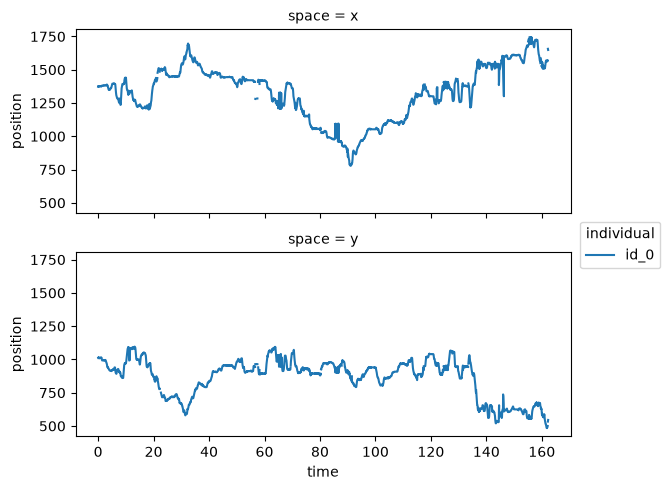

In [17]:
#we want to see the position of the headcap across space
headcap_pos=ds.position.sel(keypoint="headcap")
headcap_pos.plot.line(x="time", hue="individual", row="space", aspect=2, size=2.5)